In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import DBSCAN
import warnings, os, joblib
warnings.filterwarnings("ignore")
print("✅ Ready")

✅ Ready


In [7]:
DATA_PATH = "../ml-service/data/crime_data.csv"

df = pd.read_csv(DATA_PATH)

if "year" not in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["year"] = df["date"].dt.year

print(f"✅ Loaded {len(df):,} records  |  Years: {sorted(df['year'].dropna().unique().astype(int).tolist())}")
print(f"📋 Columns: {list(df.columns)}")
df.head()

✅ Loaded 9,800 records  |  Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
📋 Columns: ['incident_id', 'district', 'police_division', 'crime_type', 'date', 'day_of_week', 'is_holiday', 'time_bracket', 'location_type', 'lighting_level', 'victim_gender', 'victim_age_bracket', 'prior_offenses', 'offender_drug_history', 'reported_2015_total', 'solved_2015_total', 'cleared_rate_pct', 'reported_status', 'referral_source', 'year']


,incident_id,district,police_division,crime_type,date,day_of_week,is_holiday,time_bracket,location_type,lighting_level,victim_gender,victim_age_bracket,prior_offenses,offender_drug_history,reported_2015_total,solved_2015_total,cleared_rate_pct,reported_status,referral_source,year
0,2015-COL-001,Colombo,Colombo South,Homicide,2015-01-08,Thursday,Yes,Night,Public Space,Poorly-lit,Male,35-45,0,No,568,540,95,Solved,Police,2015
1,2015-COL-002,Colombo,Nugegoda,House Breaking,2015-04-14,Tuesday,Yes,Night,Residential,Dark,Female,45-60,1,No,9245,3050,33,Under Investigation,Police,2015
2,2015-GAM-001,Gampaha,Kelaniya,Drug Offences (Heroin),2015-02-15,Sunday,No,Morning,Transport Hub,Well-lit,Male,18-24,3,Yes,26145,25000,95,Solved,Police,2015
3,2015-KAN-001,Kandy,Kandy Central,Robbery,2015-08-10,Monday,No,Evening,Commercial,Well-lit,Male,25-35,2,No,3542,2300,65,Solved,Self-Reported,2015
4,2015-KAL-001,Kalutara,Panadura,Grievous Hurt,2015-03-22,Sunday,No,Evening,Public Space,Poorly-lit,Male,25-35,1,No,1410,1290,91,Solved,Hospital,2015


In [8]:
for col in ["district","crime_type","location_type","lighting_level","time_bracket"]:
    if col in df.columns:
        print(f"  ✅ {col}: {df[col].nunique()} unique values")
    else:
        print(f"  ⚠️  Missing column: {col}")

  ✅ district: 22 unique values
  ✅ crime_type: 59 unique values
  ✅ location_type: 9 unique values
  ✅ lighting_level: 3 unique values
  ✅ time_bracket: 4 unique values


In [9]:
DISTRICT_COORDS = {
    "Colombo":      (6.9271,  79.8612),
    "Gampaha":      (7.0873,  79.9996),
    "Kalutara":     (6.5854,  79.9607),
    "Kandy":        (7.2906,  80.6337),
    "Matale":       (7.4675,  80.6234),
    "Nuwara Eliya": (6.9497,  80.7891),
    "Galle":        (6.0535,  80.2210),
    "Matara":       (5.9549,  80.5550),
    "Hambantota":   (6.1429,  81.1212),
    "Jaffna":       (9.6615,  80.0255),
    "Kilinochchi":  (9.3803,  80.4036),
    "Mannar":       (8.9762,  79.9045),
    "Vavuniya":     (8.7542,  80.4982),
    "Mullaitivu":   (9.2671,  80.8128),
    "Batticaloa":   (7.7170,  81.6924),
    "Ampara":       (7.2912,  81.6727),
    "Trincomalee":  (8.5874,  81.2152),
    "Kurunegala":   (7.4818,  80.3609),
    "Puttalam":     (8.0362,  79.8283),
    "Anuradhapura": (8.3114,  80.4037),
    "Polonnaruwa":  (7.9403,  81.0188),
    "Badulla":      (6.9934,  81.0550),
    "Monaragala":   (6.8728,  81.3506),
    "Ratnapura":    (6.6828,  80.3992),
    "Kegalle":      (7.2513,  80.3464),
}

df["lat"] = df["district"].map(lambda d: DISTRICT_COORDS.get(str(d).strip(), (None, None))[0])
df["lng"] = df["district"].map(lambda d: DISTRICT_COORDS.get(str(d).strip(), (None, None))[1])

df_geo = df.dropna(subset=["lat","lng"]).copy()
print(f"✅ Matched: {len(df_geo):,}")

unmatched = df[df["lat"].isna()]["district"].unique()
if len(unmatched):
    print(f"⚠️  Unmatched districts: {unmatched}")

✅ Matched: 9,800


In [10]:
np.random.seed(42)
df_geo["lat_j"] = df_geo["lat"] + np.random.uniform(-0.08, 0.08, len(df_geo))
df_geo["lng_j"] = df_geo["lng"] + np.random.uniform(-0.08, 0.08, len(df_geo))

if "prior_offenses" in df_geo.columns:
    df_geo["prior_offenses"] = pd.to_numeric(df_geo["prior_offenses"], errors="coerce").fillna(0)

print(f"✅ Jitter applied to {len(df_geo):,} points")

✅ Jitter applied to 9,800 points


In [11]:
coords     = df_geo[["lat_j","lng_j"]].values
coords_rad = np.radians(coords)

db     = DBSCAN(eps=0.05, min_samples=5, algorithm="ball_tree", metric="haversine")
labels = db.fit_predict(coords_rad)
df_geo["cluster"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()

print(f"✅ Clusters detected: {n_clusters}")
print(f"🔇 Noise points:      {n_noise:,}")
print(f"📊 Clustered points:  {(labels != -1).sum():,}")

✅ Clusters detected: 1
🔇 Noise points:      0
📊 Clustered points:  9,800


In [12]:
rows = []
for label in sorted(set(labels)):
    if label == -1:
        continue
    mask   = df_geo["cluster"] == label
    subset = df_geo[mask]
    count  = len(subset)

    top_district = subset["district"].value_counts().index[0]
    top_crime    = subset["crime_type"].value_counts().index[0]
    top_location = subset["location_type"].value_counts().index[0] if "location_type" in subset.columns else "N/A"
    top_time     = subset["time_bracket"].value_counts().index[0]  if "time_bracket"  in subset.columns else "N/A"

    if count >= 100:   risk = "CRITICAL"
    elif count >= 50:  risk = "HIGH"
    elif count >= 20:  risk = "MEDIUM"
    else:              risk = "LOW"

    rows.append({
        "cluster_id":   label,
        "incidents":    count,
        "risk_level":   risk,
        "top_district": top_district,
        "top_crime":    top_crime,
        "top_location": top_location,
        "peak_time":    top_time,
        "center_lat":   round(subset["lat_j"].mean(), 4),
        "center_lng":   round(subset["lng_j"].mean(), 4),
    })

cluster_df = pd.DataFrame(rows).sort_values("incidents", ascending=False)
print(cluster_df.to_string(index=False))

 cluster_id  incidents risk_level top_district      top_crime top_location peak_time  center_lat  center_lng
          0       9800   CRITICAL      Colombo House Breaking  Residential     Night      7.3751     80.4323


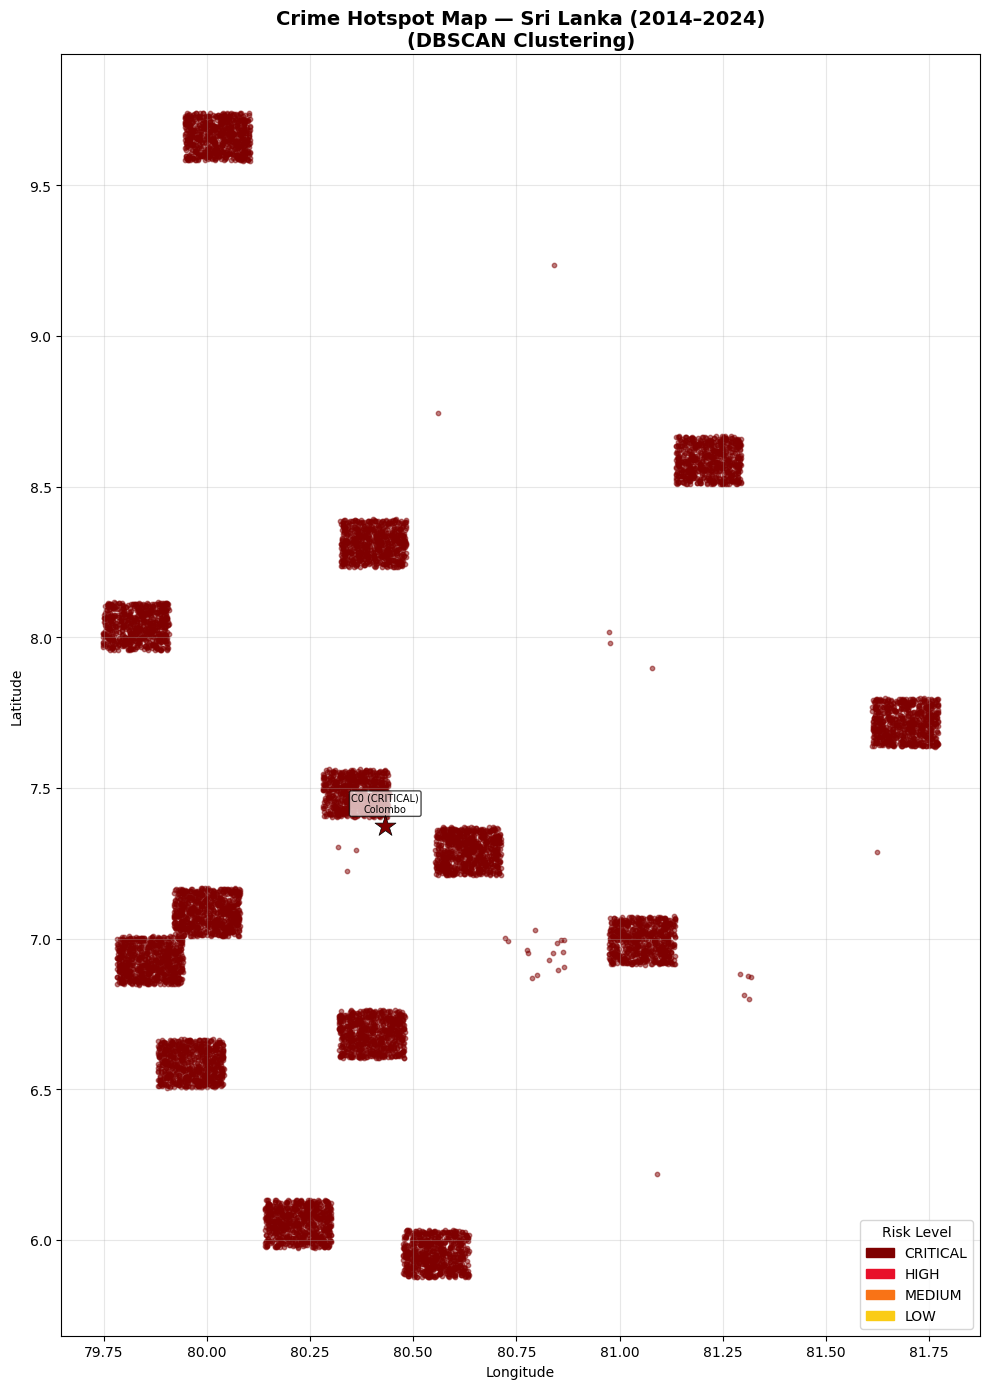

✅ Hotspot map saved


In [13]:
RISK_COLORS = {"CRITICAL":"#7f0000","HIGH":"#e8102a","MEDIUM":"#f97316","LOW":"#facc15"}

plt.figure(figsize=(10, 14))

noise_mask = df_geo["cluster"] == -1
plt.scatter(df_geo[noise_mask]["lng_j"], df_geo[noise_mask]["lat_j"],
            c="#d1d5db", s=4, alpha=0.3, label="Noise")

for _, row in cluster_df.iterrows():
    mask   = df_geo["cluster"] == row["cluster_id"]
    subset = df_geo[mask]
    color  = RISK_COLORS[row["risk_level"]]
    plt.scatter(subset["lng_j"], subset["lat_j"], c=color, s=10, alpha=0.5)
    plt.scatter(row["center_lng"], row["center_lat"],
                c=color, s=250, marker="*", edgecolors="black", linewidths=0.5, zorder=5)
    plt.annotate(
        f"C{row['cluster_id']} ({row['risk_level']})\n{row['top_district']}",
        (row["center_lng"], row["center_lat"]),
        fontsize=7, ha="center", va="bottom",
        xytext=(0, 8), textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7)
    )

patches = [mpatches.Patch(color=c, label=r) for r, c in RISK_COLORS.items()]
plt.legend(handles=patches, title="Risk Level", loc="lower right")
plt.title("Crime Hotspot Map — Sri Lanka (2014–2024)\n(DBSCAN Clustering)", fontsize=14, fontweight="bold")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("hotspot_map.png", dpi=150)
plt.show()
print("✅ Hotspot map saved")

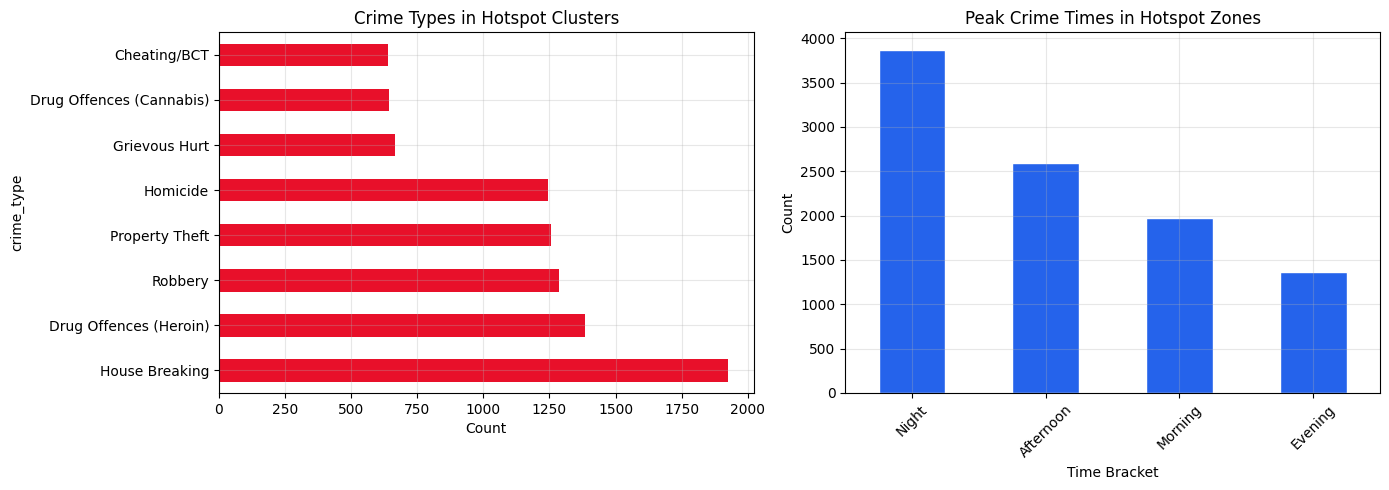

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_crimes = df_geo[df_geo["cluster"] != -1]["crime_type"].value_counts().head(8)
cluster_crimes.plot(kind="barh", ax=axes[0], color="#e8102a")
axes[0].set_title("Crime Types in Hotspot Clusters")
axes[0].set_xlabel("Count"); axes[0].grid(True, alpha=0.3)

if "time_bracket" in df_geo.columns:
    time_counts = df_geo[df_geo["cluster"] != -1]["time_bracket"].value_counts()
    time_counts.plot(kind="bar", ax=axes[1], color="#2563eb", edgecolor="white")
    axes[1].set_title("Peak Crime Times in Hotspot Zones")
    axes[1].set_xlabel("Time Bracket"); axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=45); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("hotspot_analysis.png", dpi=150)
plt.show()

In [15]:
os.makedirs("./trained", exist_ok=True)
cluster_df.to_csv("./trained/hotspot_clusters.csv", index=False)
joblib.dump(db,     "./trained/dbscan_model.pkl")
joblib.dump(df_geo, "./trained/geo_data.pkl")
print("✅ DBSCAN results saved → ./trained/")

✅ DBSCAN results saved → ./trained/
